# Notebook 09: Crossover Analysis

**One Sensor, One Year — Edition 2: US Grid**

Milestones the headlines miss. On how many days in 2025 did wind + solar out-produce **coal**? Out-produce **nuclear**? On how many did **clean** (W+S+Nuclear+Hydro) beat **fossil** (Coal+Gas+Oil)? These crossovers tell the transition story at daily resolution.

**Input:** `../data/processed/us48_2025_derived.csv`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
df = pd.read_csv(PROCESSED / 'us48_2025_derived.csv', parse_dates=['date'], index_col='date').sort_index()

# Derived aggregates
df['wind_solar'] = df[[c for c in ['WND', 'SUN'] if c in df.columns]].sum(axis=1, min_count=1)
df['renewables'] = df[[c for c in ['WND', 'SUN', 'GEO', 'SNB', 'WNB'] if c in df.columns]].sum(axis=1, min_count=1)
df['clean']      = df[[c for c in ['NUC', 'WND', 'SUN', 'WAT', 'GEO', 'SNB', 'WNB'] if c in df.columns]].sum(axis=1, min_count=1)
df['fossil']     = df[[c for c in ['COL', 'NG', 'OIL', 'OTH'] if c in df.columns]].sum(axis=1, min_count=1)

PALETTE = {
    'COL': '#D4890E', 'NG': '#F0C078', 'NUC': '#2A9D8F', 'WAT': '#264653',
    'WND': '#72B352', 'SUN': '#F4C430',
    'wind_solar': '#E67E22', 'renewables': '#27AE60', 'clean': '#2ECC71', 'fossil': '#922B21',
}
print(f'Rows: {len(df)}, derived cols: {["wind_solar","renewables","clean","fossil"]}')

Rows: 365, derived cols: ['wind_solar', 'renewables', 'clean', 'fossil']


## 1. Crossover scoreboard

Each line: did A beat B on day D? Sum across 365 days.

In [2]:
crossovers = [
    ('wind_solar', 'NUC', 'Wind+Solar > Nuclear'),
    ('wind_solar', 'COL', 'Wind+Solar > Coal'),
    ('wind_solar', 'NG',  'Wind+Solar > Gas'),
    ('wind_solar', 'WAT', 'Wind+Solar > Hydro'),
    ('renewables', 'NUC', 'Renewables > Nuclear'),
    ('renewables', 'COL', 'Renewables > Coal'),
    ('SUN', 'NUC',  'Solar > Nuclear'),
    ('SUN', 'WND',  'Solar > Wind'),
    ('SUN', 'WAT',  'Solar > Hydro'),
    ('WND', 'NUC',  'Wind > Nuclear'),
    ('WND', 'COL',  'Wind > Coal'),
    ('WAT', 'NUC',  'Hydro > Nuclear'),
    ('clean', 'fossil', 'Clean > Fossil'),
]

print('CROSSOVER SCOREBOARD — US48 2025')
print('=' * 78)
print(f'{"Matchup":28s} {"Days":>6s} {"of 365":>7s} {"First":>12s} {"Last":>12s}')
print('-' * 78)

score = []
for a, b, label in crossovers:
    if a not in df.columns or b not in df.columns:
        continue
    mask = df[a] > df[b]
    days = int(mask.sum())
    pct = days / len(df) * 100
    if days > 0:
        first = df[mask].index.min().strftime('%b %d')
        last  = df[mask].index.max().strftime('%b %d')
    else:
        first = last = 'never'
    print(f'{label:28s} {days:6d} {pct:6.1f}% {first:>12s} {last:>12s}')
    score.append({'matchup': label, 'days': days, 'pct': pct})

CROSSOVER SCOREBOARD — US48 2025
Matchup                        Days  of 365        First         Last
------------------------------------------------------------------------------
Wind+Solar > Nuclear            127   34.8%       Jan 17       Dec 29
Wind+Solar > Coal               167   45.8%       Jan 18       Dec 29
Wind+Solar > Gas                  0    0.0%        never        never
Wind+Solar > Hydro              365  100.0%       Jan 01       Dec 31
Renewables > Nuclear            134   36.7%       Jan 17       Dec 29
Renewables > Coal               170   46.6%       Jan 18       Dec 29
Solar > Nuclear                   0    0.0%        never        never
Solar > Wind                     62   17.0%       May 07       Oct 08
Solar > Hydro                   223   61.1%       Feb 01       Nov 16
Wind > Nuclear                    6    1.6%       Mar 18       Oct 20
Wind > Coal                      51   14.0%       Feb 01       Dec 29
Hydro > Nuclear                   0    0.0%     

## 2. Wind + Solar vs Coal — the headline crossover

Which beats which, day by day? Green fill = W+S ahead; orange = Coal ahead.

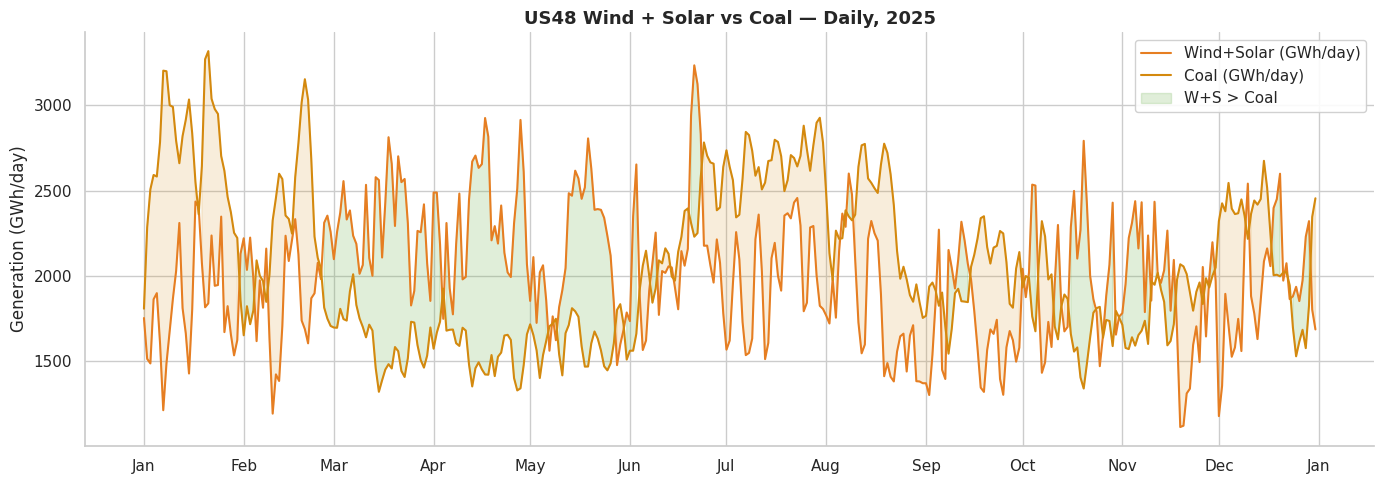

W+S beat Coal on 167 of 365 days (45.8%)
W+S daily average: 2,002 GWh vs Coal: 2,059 GWh


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['wind_solar'] / 1e3, color=PALETTE['wind_solar'], linewidth=1.5, label='Wind+Solar (GWh/day)')
ax.plot(df.index, df['COL'] / 1e3,       color=PALETTE['COL'],       linewidth=1.5, label='Coal (GWh/day)')
ax.fill_between(df.index, df['wind_solar']/1e3, df['COL']/1e3,
                where=(df['wind_solar'] > df['COL']), color='#72B352', alpha=0.22, label='W+S > Coal')
ax.fill_between(df.index, df['wind_solar']/1e3, df['COL']/1e3,
                where=(df['wind_solar'] < df['COL']), color='#D4890E', alpha=0.15)
ax.set_ylabel('Generation (GWh/day)')
ax.set_title('US48 Wind + Solar vs Coal — Daily, 2025', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
sns.despine()
plt.tight_layout()
plt.show()

wins = (df['wind_solar'] > df['COL']).sum()
print(f'W+S beat Coal on {wins} of {len(df)} days ({wins/len(df)*100:.1f}%)')
ws_avg = df['wind_solar'].mean() / 1e3
col_avg = df['COL'].mean() / 1e3
print(f'W+S daily average: {ws_avg:,.0f} GWh vs Coal: {col_avg:,.0f} GWh')

## 3. Wind + Solar vs Nuclear

Nuclear is the metronome. W+S is the wildcard. How often does the wildcard win?

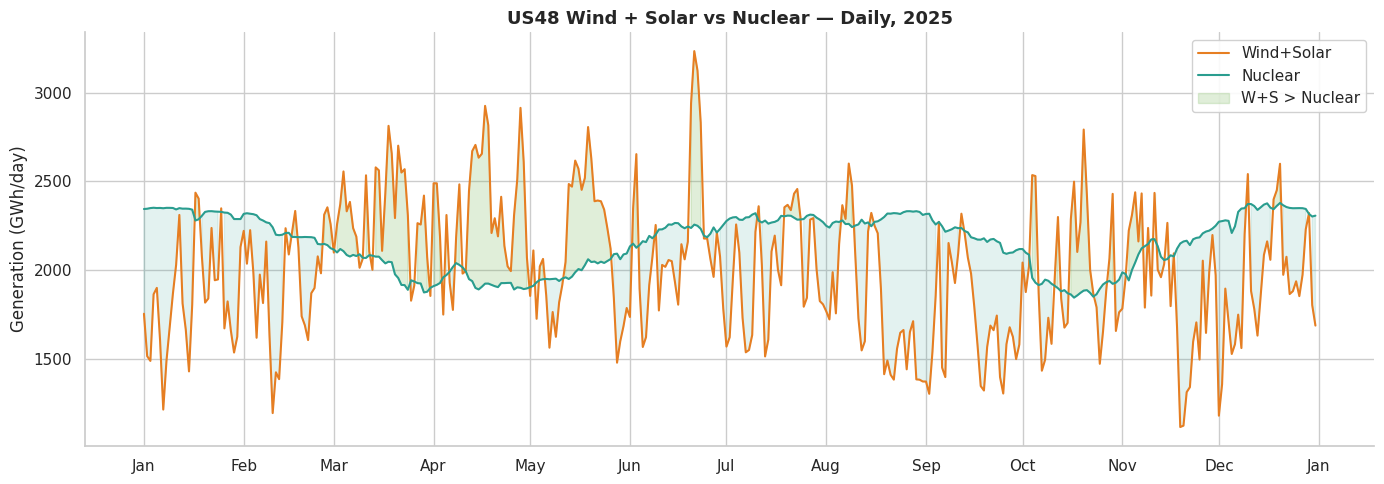

W+S beat Nuclear on 127 of 365 days (34.8%)


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['wind_solar'] / 1e3, color=PALETTE['wind_solar'], linewidth=1.5, label='Wind+Solar')
ax.plot(df.index, df['NUC'] / 1e3,        color=PALETTE['NUC'],        linewidth=1.5, label='Nuclear')
ax.fill_between(df.index, df['wind_solar']/1e3, df['NUC']/1e3,
                where=(df['wind_solar'] > df['NUC']), color='#72B352', alpha=0.22, label='W+S > Nuclear')
ax.fill_between(df.index, df['wind_solar']/1e3, df['NUC']/1e3,
                where=(df['wind_solar'] < df['NUC']), color='#2A9D8F', alpha=0.13)
ax.set_ylabel('Generation (GWh/day)')
ax.set_title('US48 Wind + Solar vs Nuclear — Daily, 2025', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
sns.despine()
plt.tight_layout()
plt.show()

wins = (df['wind_solar'] > df['NUC']).sum()
print(f'W+S beat Nuclear on {wins} of {len(df)} days ({wins/len(df)*100:.1f}%)')

## 4. Solar vs Wind — the internal race

Wind dominates US renewable output annually (~463 TWh vs 267 TWh), but solar has a diurnal advantage and a summer peak. When does each win?

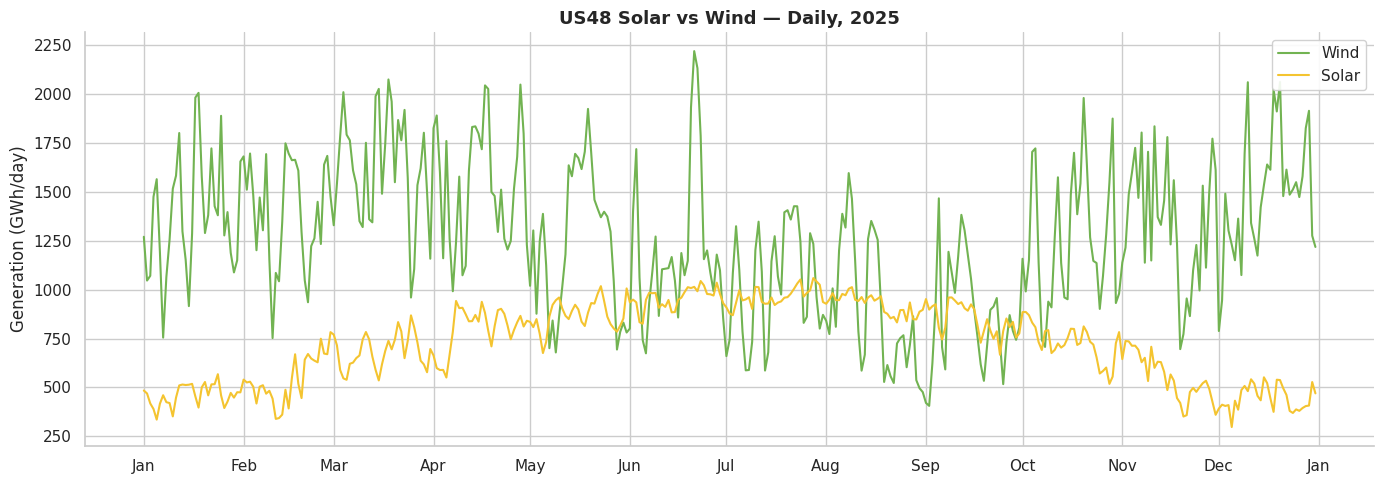

Solar beat Wind on 62 of 365 days (17.0%)
Wind annual: 463 TWh, Solar annual: 267 TWh


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['WND'] / 1e3, color=PALETTE['WND'], linewidth=1.5, label='Wind')
ax.plot(df.index, df['SUN'] / 1e3, color=PALETTE['SUN'], linewidth=1.5, label='Solar')
ax.set_ylabel('Generation (GWh/day)')
ax.set_title('US48 Solar vs Wind — Daily, 2025', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
sns.despine()
plt.tight_layout()
plt.show()

solar_wins = (df['SUN'] > df['WND']).sum()
print(f'Solar beat Wind on {solar_wins} of {len(df)} days ({solar_wins/len(df)*100:.1f}%)')
print(f'Wind annual: {df["WND"].sum()/1e6:.0f} TWh, Solar annual: {df["SUN"].sum()/1e6:.0f} TWh')

## 5. Cumulative crossover count through the year

Lines hugging the diagonal dashed reference = that crossover happens nearly every day. Curves flattening = rare event.

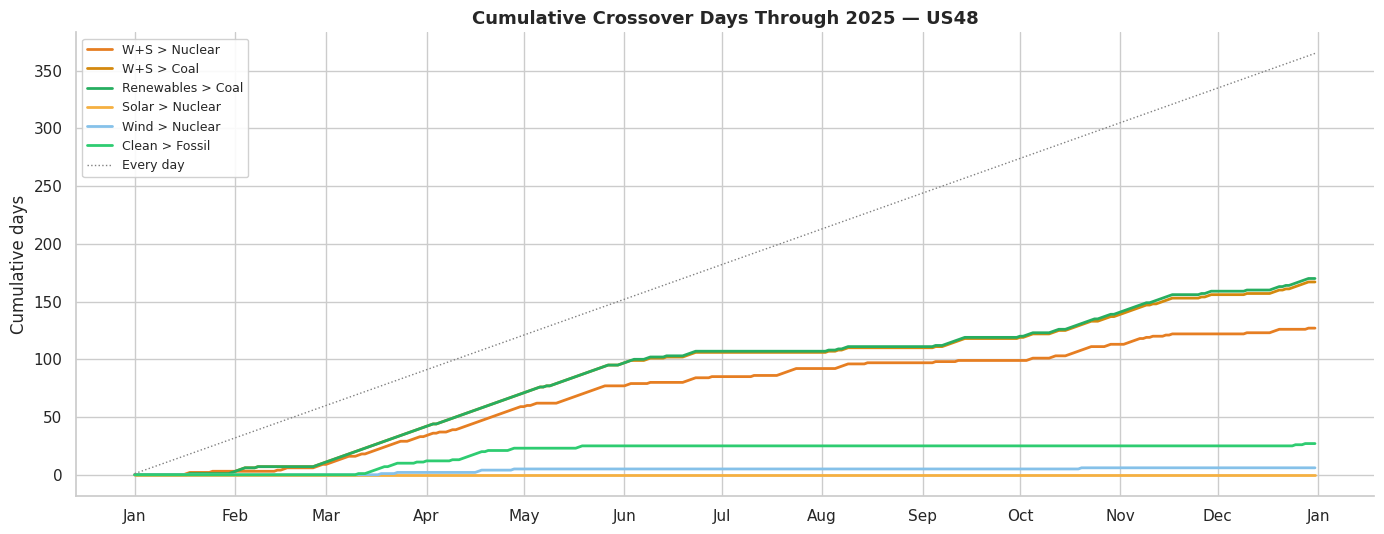

In [6]:
key = [
    ('wind_solar', 'NUC', 'W+S > Nuclear',   '#E67E22'),
    ('wind_solar', 'COL', 'W+S > Coal',      '#D4890E'),
    ('renewables', 'COL', 'Renewables > Coal', '#27AE60'),
    ('SUN', 'NUC',        'Solar > Nuclear', '#F5B041'),
    ('WND', 'NUC',        'Wind > Nuclear',  '#85C1E9'),
    ('clean', 'fossil',   'Clean > Fossil',  '#2ECC71'),
]

fig, ax = plt.subplots(figsize=(14, 5.5))
for a, b, label, color in key:
    cumcount = (df[a] > df[b]).cumsum()
    ax.plot(df.index, cumcount.values, color=color, linewidth=2, label=label)

ax.plot(df.index, np.arange(1, len(df) + 1), color='grey', linestyle=':', linewidth=1, label='Every day')
ax.set_ylabel('Cumulative days')
ax.set_title('Cumulative Crossover Days Through 2025 — US48',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
sns.despine()
plt.tight_layout()
plt.show()

## 6. Gap charts — the size of each crossover

Positive (green) bar = W+S won that day; negative (orange) = opponent won. Size = margin.

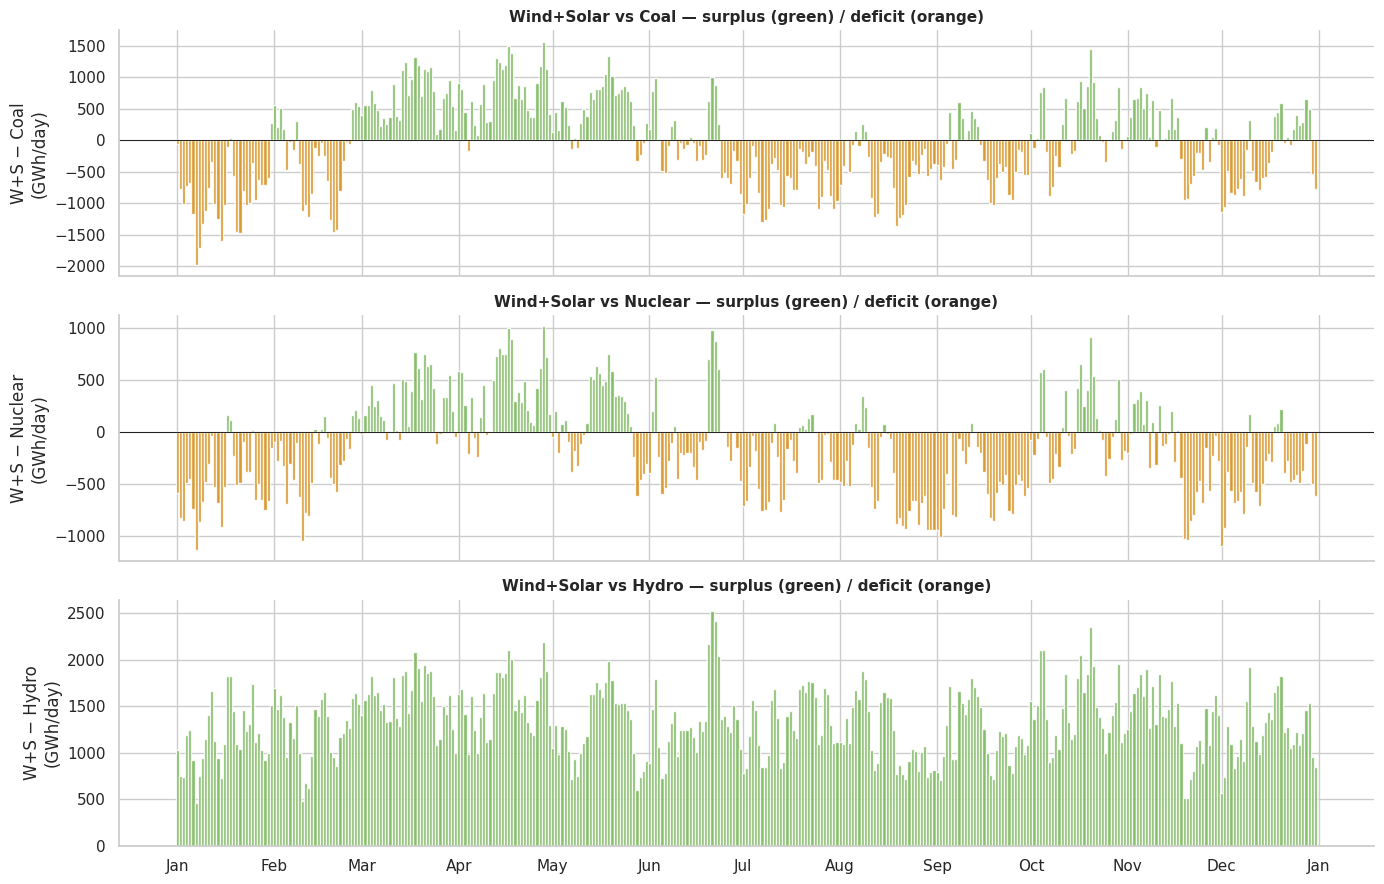

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, (col, label) in zip(axes, [('COL', 'Coal'), ('NUC', 'Nuclear'), ('WAT', 'Hydro')]):
    gap = (df['wind_solar'] - df[col]) / 1e3
    colors = ['#72B352' if v > 0 else '#D4890E' for v in gap]
    ax.bar(df.index, gap, color=colors, width=1.0, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_ylabel(f'W+S − {label}\n(GWh/day)')
    ax.set_title(f'Wind+Solar vs {label} — surplus (green) / deficit (orange)',
                 fontsize=11, fontweight='bold')
    sns.despine(ax=ax)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

## Key findings

1. **Wind + Solar now beat Coal on most days of 2025.** A milestone worth naming — the US generation mix has tipped.
2. **Wind + Solar vs Nuclear is essentially a daily race.** Nuclear ≈ 2,150 GWh/day; W+S ≈ 2,000 GWh/day, so they trade the lead all year.
3. **Wind + Solar almost never beat Gas.** Natural gas is the US's ~1,680 TWh giant; W+S would need to ~3× to catch it on an average day.
4. **Solar beats Wind in summer** (longer days, lower wind). Wind beats Solar in spring and winter.
5. **Clean > Fossil on some days — especially spring weekends** when wind + solar + nuclear surge while gas/coal ramps down.
6. **The cumulative chart tells the story visually** — lines hugging the 'every day' reference mean that crossover is now routine; flat curves mean it's exceptional.

→ Next: Notebook 10 — Art Prototypes